<a href="https://colab.research.google.com/github/kakakeyvan/Bear_Distribution/blob/main/bear_distribution_shur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

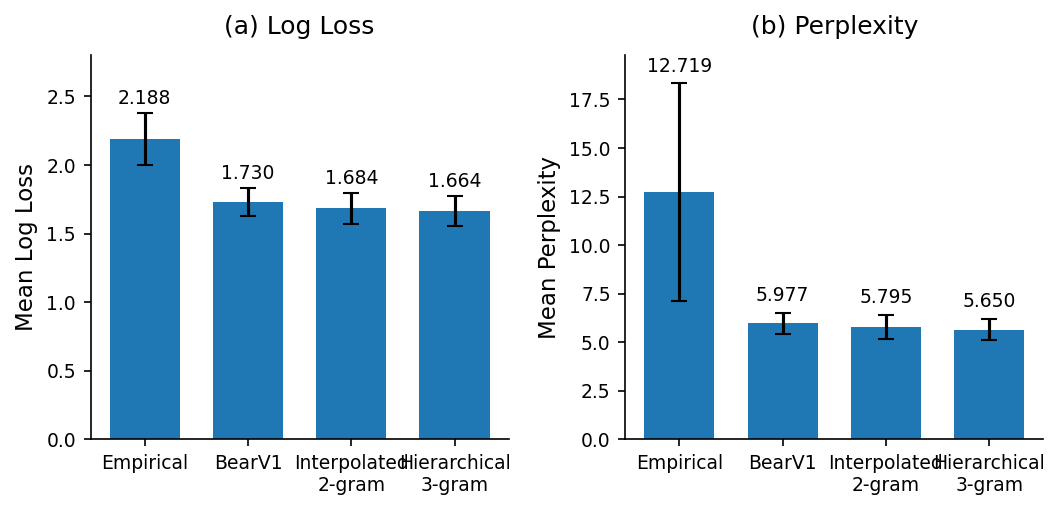

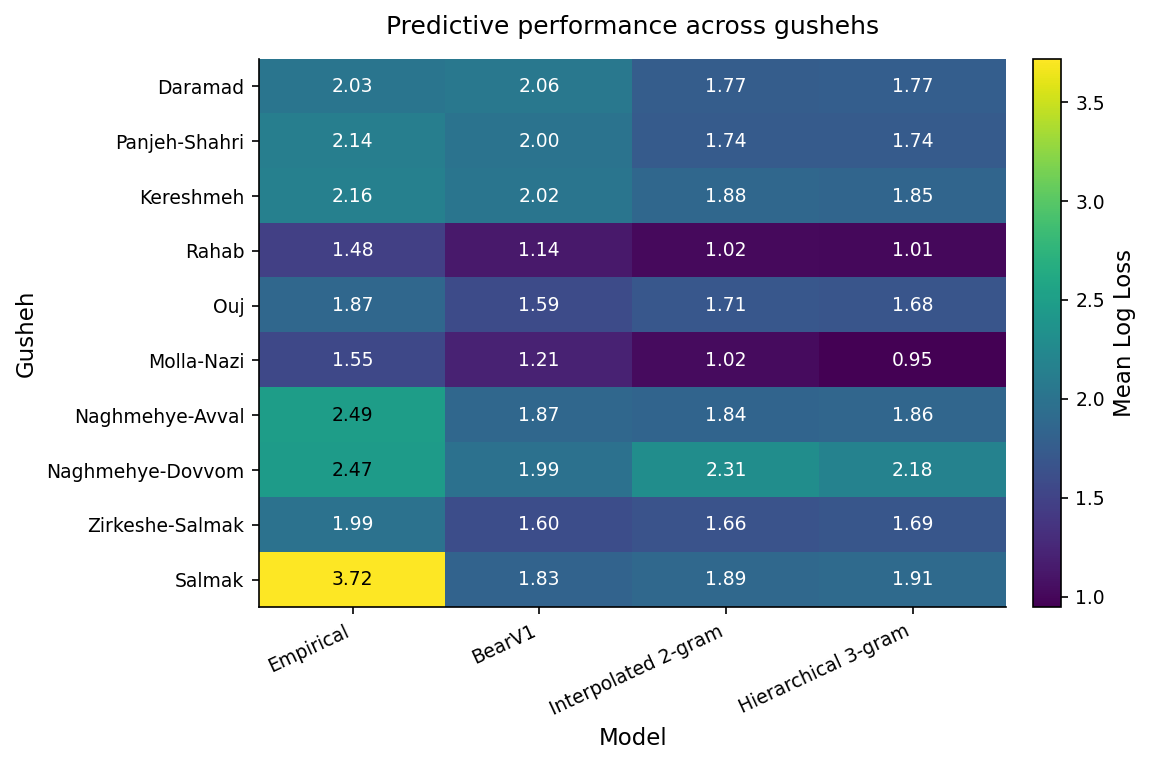

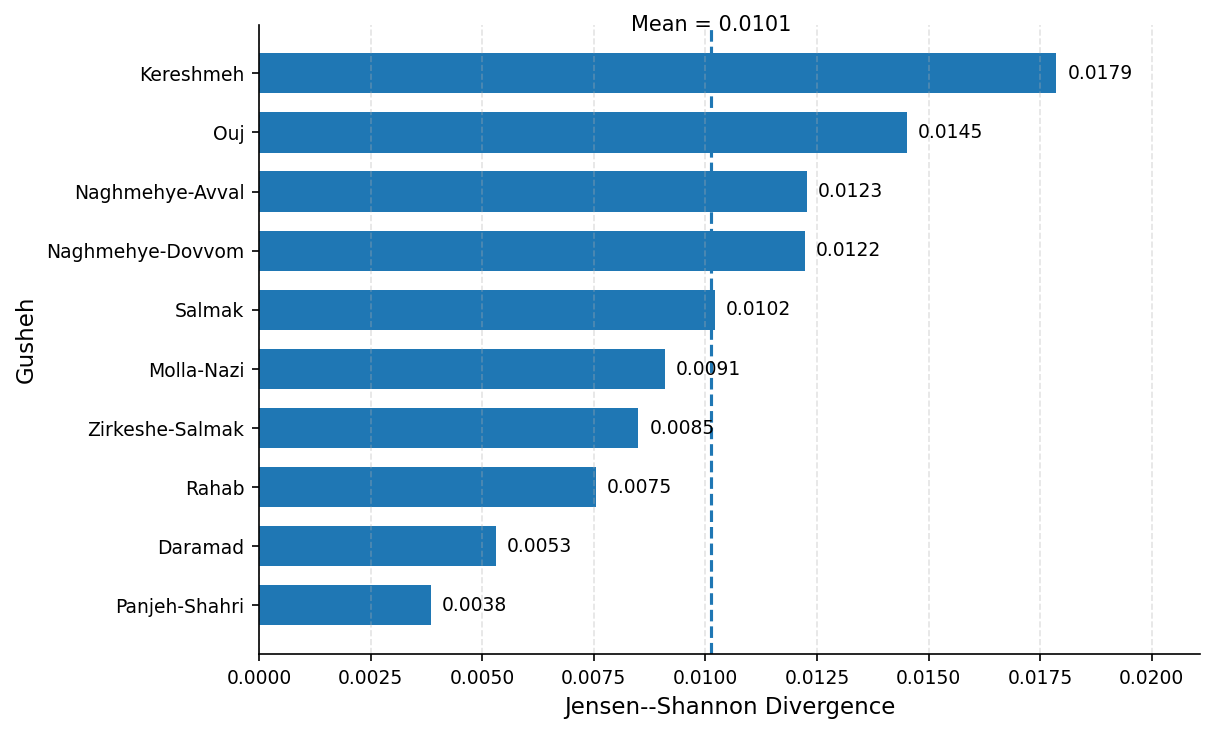

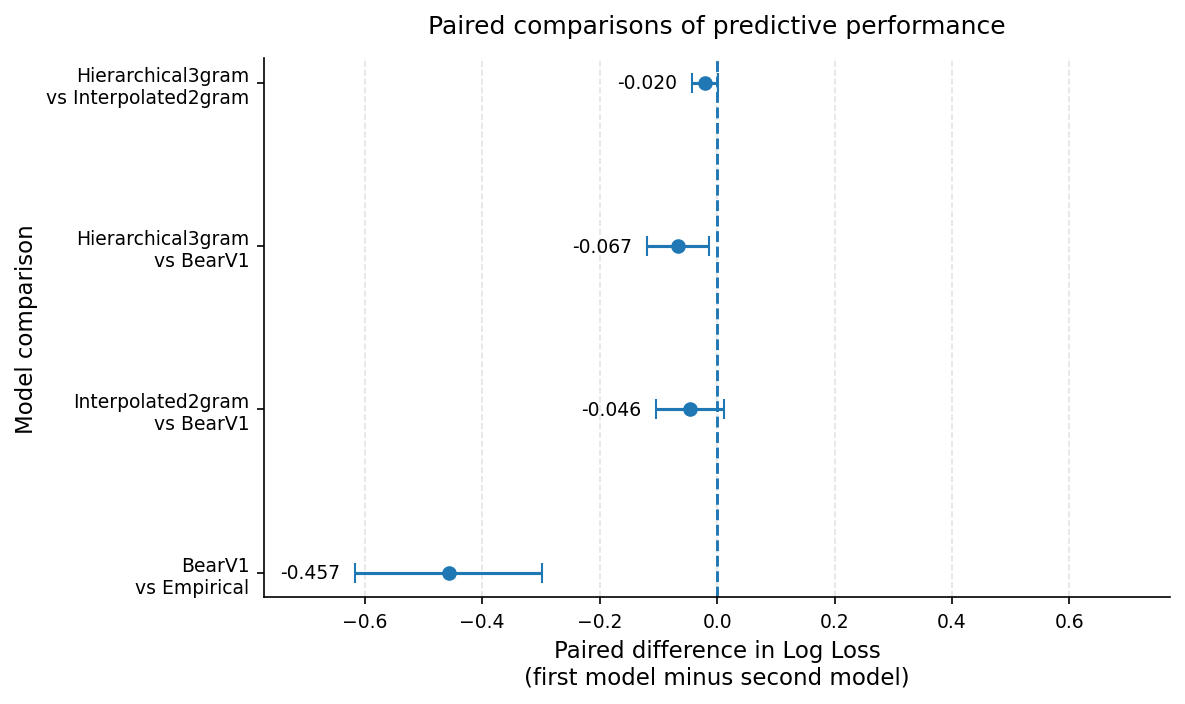

BAYESIAN / Bear Distribution
Publication-quality figures generated successfully.

Output directory:
/content/BEAR_DISTRIBUTION_FIGURES

Generated figures:
  Figure_1_Overall_Performance.pdf
  Figure_1_Overall_Performance.png
  Figure_1_Overall_Performance_95CI.pdf
  Figure_1_Overall_Performance_95CI.png
  Figure_1_data.csv
  Figure_2_Gusheh_LogLoss_Heatmap.pdf
  Figure_2_Gusheh_LogLoss_Heatmap.png
  Figure_2_data.csv
  Figure_3_JS_Divergence.pdf
  Figure_3_JS_Divergence.png
  Figure_3_data.csv
  Figure_4_Paired_LogLoss_Comparisons.pdf
  Figure_4_Paired_LogLoss_Comparisons.png

95% CI critical value:
  t(49) = 2.0096

Mean JS divergence:
  0.010136

Paired comparisons:
----------------------------------------------------------------------
BearV1 vs Empirical                           Mean = -0.457332 | SD = 0.561842 | 95% CI = [-0.617005, -0.297658]
Interpolated2gram vs BearV1                   Mean = -0.046212 | SD = 0.201251 | 95% CI = [-0.103407, 0.010983]
Hierarchical3gram vs BearV1

In [ ]:

# ============================================================
# BAYESIAN / BEAR DISTRIBUTION
# Publication-quality figures for Journal of New Music Research
#
# Generates:
#   Figure 1 - Overall predictive performance
#   Figure 2 - Gusheh-level Log Loss heatmap
#   Figure 3 - Jensen-Shannon divergence
#   Figure 4 - Paired Log Loss comparisons
#
# Output:
#   /content/BEAR_DISTRIBUTION_FIGURES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------

OUTDIR = "/content/BEAR_DISTRIBUTION_FIGURES"
os.makedirs(OUTDIR, exist_ok=True)

# Publication-friendly defaults
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ------------------------------------------------------------
# 2. Overall predictive results
# ------------------------------------------------------------

models = [
    "Empirical",
    "BearV1",
    "Interpolated\n2-gram",
    "Hierarchical\n3-gram"
]

mean_ll = np.array([
    2.187800,
    1.730468,
    1.684256,
    1.663784
])

sd_ll = np.array([
    0.662371,
    0.348072,
    0.393719,
    0.388633
])

mean_ppl = np.array([
    12.719279,
    5.977056,
    5.794933,
    5.650200
])

sd_ppl = np.array([
    19.751798,
    1.951559,
    2.153261,
    1.925389
])

N_SPLITS = 50
T_CRIT = t.ppf(0.975, df=N_SPLITS - 1)

# 95% CI of the mean
ci_ll = T_CRIT * sd_ll / np.sqrt(N_SPLITS)
ci_ppl = T_CRIT * sd_ppl / np.sqrt(N_SPLITS)

# ------------------------------------------------------------
# Figure 1
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(7.2, 3.5)
)

x = np.arange(len(models))

# ---- Panel A: Log Loss ----
ax = axes[0]

ax.bar(
    x,
    mean_ll,
    yerr=ci_ll,
    capsize=4,
    width=0.68
)

ax.set_title("(a) Log Loss", pad=10)
ax.set_ylabel("Mean Log Loss")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ll + ci_ll) * 1.18)

for i, value in enumerate(mean_ll):
    ax.text(
        i,
        mean_ll[i] + ci_ll[i] + 0.04,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ---- Panel B: Perplexity ----
ax = axes[1]

ax.bar(
    x,
    mean_ppl,
    yerr=ci_ppl,
    capsize=4,
    width=0.68
)

ax.set_title("(b) Perplexity", pad=10)
ax.set_ylabel("Mean Perplexity")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ppl + ci_ppl) * 1.08)

for i, value in enumerate(mean_ppl):
    ax.text(
        i,
        mean_ppl[i] + ci_ppl[i] + 0.4,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.tight_layout()

fig.savefig(
    os.path.join(OUTDIR, "Figure_1_Overall_Performance_95CI.pdf"),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(OUTDIR, "Figure_1_Overall_Performance_95CI.png"),
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 3. Gusheh-level predictive results
# ============================================================

gushehs = [
    "Daramad",
    "Panjeh-Shahri",
    "Kereshmeh",
    "Rahab",
    "Ouj",
    "Molla-Nazi",
    "Naghmehye-Avval",
    "Naghmehye-Dovvom",
    "Zirkeshe-Salmak",
    "Salmak"
]

gusheh_ll = np.array([
    [2.026020, 2.059059, 1.769841, 1.771119],
    [2.136367, 1.999578, 1.740021, 1.739062],
    [2.158422, 2.021765, 1.878295, 1.851582],
    [1.476938, 1.141378, 1.019362, 1.011400],
    [1.871309, 1.586200, 1.705132, 1.682933],
    [1.545892, 1.212112, 1.024616, 0.947975],
    [2.488491, 1.869944, 1.843526, 1.859179],
    [2.469854, 1.985247, 2.310433, 2.175650],
    [1.986924, 1.601932, 1.662065, 1.689464],
    [3.717781, 1.827466, 1.889268, 1.909473]
])

heatmap_columns = [
    "Empirical",
    "BearV1",
    "Interpolated 2-gram",
    "Hierarchical 3-gram"
]

# ------------------------------------------------------------
# Figure 2 - Heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)

im = ax.imshow(
    gusheh_ll,
    aspect="auto"
)

ax.set_xticks(np.arange(len(heatmap_columns)))
ax.set_xticklabels(
    heatmap_columns,
    rotation=25,
    ha="right"
)

ax.set_yticks(np.arange(len(gushehs)))
ax.set_yticklabels(gushehs)

ax.set_xlabel("Model")
ax.set_ylabel("Gusheh")
ax.set_title(
    "Predictive performance across gushehs",
    pad=12
)

# Annotate cells
threshold = (gusheh_ll.max() + gusheh_ll.min()) / 2

for i in range(gusheh_ll.shape[0]):
    for j in range(gusheh_ll.shape[1]):

        value = gusheh_ll[i, j]

        text_color = "white" if value < threshold else "black"

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label("Mean Log Loss")

fig.tight_layout()

fig.savefig(
    os.path.join(OUTDIR, "Figure_2_Gusheh_LogLoss_Heatmap.pdf"),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(OUTDIR, "Figure_2_Gusheh_LogLoss_Heatmap.png"),
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 4. Jensen-Shannon divergence
# ============================================================

js_values = {
    "Daramad": 0.005302,
    "Panjeh-Shahri": 0.003843,
    "Kereshmeh": 0.017866,
    "Rahab": 0.007546,
    "Ouj": 0.014509,
    "Molla-Nazi": 0.009091,
    "Naghmehye-Avval": 0.012270,
    "Naghmehye-Dovvom": 0.012231,
    "Zirkeshe-Salmak": 0.008495,
    "Salmak": 0.010203
}

# Sort from highest to lowest
js_sorted = sorted(
    js_values.items(),
    key=lambda x: x[1],
    reverse=True
)

js_names = [x[0] for x in js_sorted]
js_scores = np.array([x[1] for x in js_sorted])

mean_js = js_scores.mean()

# ------------------------------------------------------------
# Figure 3
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.2, 5.0)
)

y = np.arange(len(js_names))

ax.barh(
    y,
    js_scores,
    height=0.68
)

ax.set_yticks(y)
ax.set_yticklabels(js_names)

ax.invert_yaxis()

ax.set_xlabel("Jensen--Shannon Divergence")
ax.set_ylabel("Gusheh")

ax.axvline(
    mean_js,
    linestyle="--",
    linewidth=1.5
)

ax.text(
    mean_js,
    -0.65,
    f"Mean = {mean_js:.4f}",
    ha="center",
    va="bottom",
    fontsize=10
)

# Numerical labels
for i, value in enumerate(js_scores):
    ax.text(
        value + 0.00025,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(
    0,
    max(js_scores) * 1.18
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

fig.tight_layout()

fig.savefig(
    os.path.join(OUTDIR, "Figure_3_JS_Divergence.pdf"),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(OUTDIR, "Figure_3_JS_Divergence.png"),
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 5. Paired statistical comparisons
#
# IMPORTANT:
# These are the paired split-level results from the 50
# unique structural evaluation splits.
#
# Difference is defined as:
#
#   First model - Second model
#
# Therefore:
#
#   negative value = first model has lower Log Loss
#
# 95% CI is computed from the paired differences.
# ============================================================

comparisons = [
    "BearV1\nvs Empirical",
    "Interpolated2gram\nvs BearV1",
    "Hierarchical3gram\nvs BearV1",
    "Hierarchical3gram\nvs Interpolated2gram"
]

# Mean paired differences
paired_mean = np.array([
    -0.45733161,
    -0.04621211,
    -0.06668445,
    -0.02047234
])

# Standard deviation of paired differences
paired_sd = np.array([
    0.56184209,
    0.20125063,
    0.18498725,
    0.07678059
])

paired_ci = (
    T_CRIT
    * paired_sd
    / np.sqrt(N_SPLITS)
)

# ------------------------------------------------------------
# Figure 4 - Paired comparisons
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

y = np.arange(len(comparisons))

ax.errorbar(
    paired_mean,
    y,
    xerr=paired_ci,
    fmt="o",
    markersize=6,
    capsize=5,
    linewidth=1.5
)

# Zero reference line
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.4
)

ax.set_yticks(y)
ax.set_yticklabels(comparisons)

ax.set_xlabel(
    "Paired difference in Log Loss\n"
    "(first model minus second model)"
)

ax.set_ylabel("Model comparison")

ax.set_title(
    "Paired comparisons of predictive performance",
    pad=12
)

# Add numerical mean differences
for i, (mean, ci) in enumerate(
    zip(paired_mean, paired_ci)
):

    if mean < 0:
        x_text = mean - ci - 0.025
        ha = "right"
    else:
        x_text = mean + ci + 0.025
        ha = "left"

    ax.text(
        x_text,
        i,
        f"{mean:.3f}",
        va="center",
        ha=ha,
        fontsize=9
    )

# Symmetric x limits
max_extent = np.max(
    np.abs(paired_mean) + paired_ci
)

ax.set_xlim(
    -max_extent * 1.25,
    max_extent * 1.25
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.pdf"
    ),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.png"
    ),
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# 6. Print statistical summary
# ============================================================

print("=" * 70)
print("BAYESIAN / Bear Distribution")
print("Publication-quality figures generated successfully.")
print("=" * 70)

print(f"\nOutput directory:")
print(OUTDIR)

print("\nGenerated figures:")

for filename in sorted(os.listdir(OUTDIR)):
    print(f"  {filename}")

print("\n95% CI critical value:")
print(f"  t(49) = {T_CRIT:.4f}")

print("\nMean JS divergence:")
print(f"  {mean_js:.6f}")

print("\nPaired comparisons:")
print("-" * 70)

for name, mean, sd, ci in zip(
    comparisons,
    paired_mean,
    paired_sd,
    paired_ci
):
    print(
        f"{name.replace(chr(10), ' '):45s}"
        f" Mean = {mean: .6f} | "
        f"SD = {sd:.6f} | "
        f"95% CI = [{mean-ci:.6f}, {mean+ci:.6f}]"
    )

print("\nFigure 4:")
print("  Points = mean paired Log Loss difference")
print("  Error bars = 95% confidence intervals")
print("  Zero line = no difference")
print("  Negative values = lower Log Loss for the first model")

print("\n" + "=" * 70)

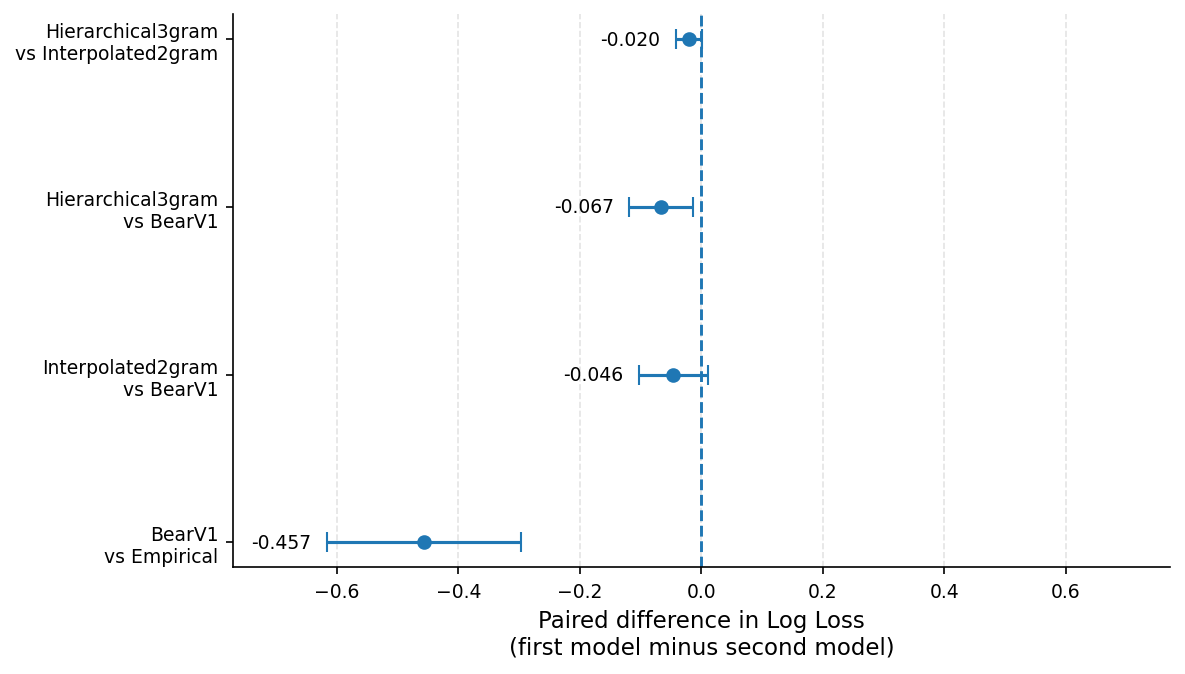

In [ ]:

# ============================================================
# Figure 4 - Paired Log Loss comparisons
# Publication version
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 4.6)
)

y = np.arange(len(comparisons))

ax.errorbar(
    paired_mean,
    y,
    xerr=paired_ci,
    fmt="o",
    markersize=6,
    capsize=5,
    linewidth=1.5
)

# Zero reference line
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.4
)

ax.set_yticks(y)
ax.set_yticklabels(comparisons)

# No unnecessary Y-axis title
ax.set_ylabel("")

ax.set_xlabel(
    "Paired difference in Log Loss\n"
    "(first model minus second model)"
)

# No title: the LaTeX caption will provide it

# Numerical mean differences
for i, (mean, ci) in enumerate(
    zip(paired_mean, paired_ci)
):

    if mean < 0:
        x_text = mean - ci - 0.025
        ha = "right"
    else:
        x_text = mean + ci + 0.025
        ha = "left"

    ax.text(
        x_text,
        i,
        f"{mean:.3f}",
        va="center",
        ha=ha,
        fontsize=9
    )

# Symmetric limits around zero
max_extent = np.max(
    np.abs(paired_mean) + paired_ci
)

ax.set_xlim(
    -max_extent * 1.25,
    max_extent * 1.25
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.pdf"
    ),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.png"
    ),
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [ ]:

# Save PDF
fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.pdf"
    ),
    format="pdf",
    bbox_inches="tight"
)

# Save PNG
fig.savefig(
    os.path.join(
        OUTDIR,
        "Figure_4_Paired_LogLoss_Comparisons.png"
    ),
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)